# Project #5 – Water Quality Analysis
## McClusky Canal System: Lake Sakakawea -> Sheyenne River -> Lake Ashtabula

This project analyzes water quality from Lake Sakakawea through the McClusky Canal to the Sheyenne River/Lake Ashtabula system. It evaluates water quality changes and estimates post-mixing TDS using data cleaning, statistics, boxplots, and a TDS mixing model.

## 1. Client Requests

- Determine whether water quality degrades from Lake Sakakawea to the end of the McClusky Canal
- Identify which water quality parameters are most concerning
- Calculate TDS concentration in Lake Ashtabula after mixing with the Sheyenne River
- Make this TDS calculation dynamic so flow rates and concentrations can be changed
- Provide boxplots for at least 4 water quality parameters
- Calculate mean, median, max, and min for each sample point and parameter of interest

## 2. Packages Used

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


> **Packages:** pandas is used for data cleaning and organization, numpy for calculations, matplotlib and seaborn for visualization.

## 3. Data Import

In [65]:
df = pd.read_csv('Project5.csv')
print('Shape:', df.shape)
df.head()

Shape: (25697, 57)


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityRelativeDepthName,...,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LastUpdated,ProviderName,activity_date,year,month,location_order,location_name
0,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-7863P,Field Msr/Obs,Water,NaN,8/16/2013,7:35:00,CST,NaN,...,NaN,NaN,NaN,2015-09-17T10:39:36Z,STORET,8/16/2013,2013,8,21NDHDWQ_WQX-382003,Lake Sakakawea
1,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-13-R1573,Sample-Routine,Water,NaN,7/8/2013,9:18:00,CST,NaN,...,NaN,NaN,NaN,2014-03-17T13:39:19Z,STORET,7/8/2013,2013,7,21NDHDWQ_WQX-381171,Lake Ashtabula
2,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-13-R2319,Sample-Routine,Water,NaN,8/19/2013,11:30:00,CST,NaN,...,NaN,NaN,NaN,2014-03-17T13:50:58Z,STORET,8/19/2013,2013,8,21NDHDWQ_WQX-381171,Lake Ashtabula
3,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-8371P,Field Msr/Obs,Water,NaN,6/27/2013,NaN,NaN,NaN,...,NaN,NaN,NaN,2017-10-06T15:07:18Z,STORET,6/27/2013,2013,6,21NDHDWQ_WQX-381171,Lake Ashtabula
4,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-8379P,Field Msr/Obs,Water,NaN,7/22/2013,NaN,NaN,NaN,...,NaN,NaN,NaN,2017-10-06T15:07:19Z,STORET,7/22/2013,2013,7,21NDHDWQ_WQX-381171,Lake Ashtabula


In [66]:
df.columns.tolist()

['OrganizationIdentifier',
 'OrganizationFormalName',
 'ActivityIdentifier',
 'ActivityTypeCode',
 'ActivityMediaName',
 'ActivityMediaSubdivisionName',
 'ActivityStartDate',
 'ActivityStartTime/Time',
 'ActivityStartTime/TimeZoneCode',
 'ActivityRelativeDepthName',
 'ActivityDepthHeightMeasure/MeasureValue',
 'ActivityDepthHeightMeasure/MeasureUnitCode',
 'ActivityTopDepthHeightMeasure/MeasureValue',
 'ActivityTopDepthHeightMeasure/MeasureUnitCode',
 'ActivityBottomDepthHeightMeasure/MeasureValue',
 'ActivityBottomDepthHeightMeasure/MeasureUnitCode',
 'ProjectIdentifier',
 'ProjectName',
 'ActivityConductingOrganizationText',
 'MonitoringLocationIdentifier',
 'MonitoringLocationName',
 'ActivityCommentText',
 'ActivityLocation/LatitudeMeasure',
 'ActivityLocation/LongitudeMeasure',
 'SampleCollectionMethod/MethodIdentifier',
 'SampleCollectionMethod/MethodIdentifierContext',
 'SampleCollectionMethod/MethodName',
 'SampleCollectionEquipmentName',
 'ResultIdentifier',
 'ResultDetectionC

## 4. Data Cleaning

In [67]:
# Check missing values in key columns
key_cols = ['CharacteristicName', 'ResultMeasureValue', 'location_name', 'ResultMeasure/MeasureUnitCode']
df[key_cols].isnull().sum()

CharacteristicName                  0
ResultMeasureValue               1671
location_name                       0
ResultMeasure/MeasureUnitCode    7898
dtype: int64

In [68]:
# Check data types
df[key_cols].dtypes

CharacteristicName                object
ResultMeasureValue               float64
location_name                     object
ResultMeasure/MeasureUnitCode     object
dtype: object

In [69]:
# Convert measurement values to numeric
df['ResultMeasureValue'] = pd.to_numeric(df['ResultMeasureValue'], errors='coerce')

# Drop rows missing key analysis columns
df_clean = df.dropna(subset=['ResultMeasureValue', 'CharacteristicName', 'location_name'])

print('Rows before cleaning:', len(df))
print('Rows after cleaning:', len(df_clean))
print('Rows removed:', len(df) - len(df_clean))

Rows before cleaning: 25697
Rows after cleaning: 24026
Rows removed: 1671


> **Cleaning notes:** The data was cleaned by converting measurements to numbers and removing incomplete rows. This made sure the analysis used complete and usable records.

## 5. Parameters of Interest

In [70]:
# View all unique parameter names in the dataset
df_clean['CharacteristicName'].unique()

array(['Specific conductance', 'Total dissolved solids', 'Sulfate', 'pH',
       'Magnesium', 'Bicarbonate', 'Sum of anions', 'Iron', 'Calcium',
       'Hardness, carbonate', 'Chloride', 'Cations-Anions', 'Sodium',
       'Sum of cations', 'Aluminum', 'Alkalinity, total', 'Manganese',
       'Conductivity',
       'Sodium adsorption ratio [(Na)/(sq root of 1/2 Ca + Mg)]',
       'Carbonate', 'Zinc', 'Selenium'], dtype=object)

In [71]:
# Filter to client-requested parameters
parameters_of_interest = [
    'Total dissolved solids',
    'Sulfate',
    'pH',
    'Magnesium',
    'Bicarbonate',
    'Calcium',
    'Hardness, carbonate',
    'Chloride',
    'Sodium',
    'Carbonate',
    'Sodium adsorption ratio [(na)/(sq root of 1/2 ca + mg)]'
]

param_df = df_clean[df_clean['CharacteristicName'].isin(parameters_of_interest)]
print('Records with parameters of interest:', len(param_df))
param_df['CharacteristicName'].value_counts()

Records with parameters of interest: 12177


CharacteristicName
pH                        5545
Sodium                    1364
Sulfate                    700
Chloride                   693
Total dissolved solids     683
Magnesium                  682
Hardness, carbonate        682
Calcium                    682
Bicarbonate                681
Carbonate                  465
Name: count, dtype: int64

> **Parameters selected:** These parameters were selected based on the client’s requirements. They include key ions, TDS, pH, hardness, and SAR to evaluate overall water quality.

## 6. Organizing Data by Location

In [72]:
# View all unique locations
df_clean['location_name'].unique()

array(['Lake Sakakawea', 'Lake Ashtabula',
       'Turtle Creek-Above Turtle Lake', 'Sheyenne River - Lisbon',
       'Sheyenne River 3', 'Red River', 'New Johns Lake - Deepest',
       'Sheyenne River - Warwick', 'West Park Lake - Deepest',
       'Heckers Lake - Deepest', 'East Park Lake - Deepest',
       'Lake Audubon - Deepest',
       'Red River near Miller Dr N, 2 MI N of Moorhead, MN',
       'Sheyenne River In Lisbon ND', 'Sheyenne River SE of Kindred',
       'Sheyenne River Nr Maddock, ND', 'Sheyenne River Nr Harvey, ND',
       'Sheyenne River 4'], dtype=object)

In [73]:
# Filter to the three main canal system locations
locations_of_interest = ['Lake Sakakawea', 'Sheyenne River - Lisbon', 'Lake Ashtabula']

# Ordered from source to destination
location_order = ['Lake Sakakawea', 'Sheyenne River - Lisbon', 'Lake Ashtabula']

filtered_df = param_df[param_df['location_name'].isin(locations_of_interest)].copy()

# Set ordered categorical for correct plot ordering
filtered_df['location_name'] = pd.Categorical(
    filtered_df['location_name'],
    categories=location_order,
    ordered=True
)

print('Records in analysis locations:', len(filtered_df))
filtered_df.groupby('location_name', observed=False)['CharacteristicName'].count()

Records in analysis locations: 9495


location_name
Lake Sakakawea             4243
Sheyenne River - Lisbon    1002
Lake Ashtabula             4250
Name: CharacteristicName, dtype: int64

## 7. Summary Statistics

In [74]:
summary_stats = filtered_df.groupby(['location_name', 'CharacteristicName'])['ResultMeasureValue'].agg(
    Mean='mean',
    Median='median',
    Min='min',
    Max='max',
    Count='count'
).round(2).reset_index()

summary_stats

C:\Users\adena\AppData\Local\Temp\ipykernel_36052\3347533616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = filtered_df.groupby(['location_name', 'CharacteristicName'])['ResultMeasureValue'].agg(


,location_name,CharacteristicName,Mean,Median,Min,Max,Count
0,Lake Sakakawea,Bicarbonate,186.37,186.00,157.00,214.00,78
1,Lake Sakakawea,Calcium,49.45,49.50,41.00,56.10,78
2,Lake Sakakawea,Carbonate,5.23,5.00,1.00,15.00,56
3,Lake Sakakawea,Chloride,10.02,10.10,8.44,11.20,78
4,Lake Sakakawea,"Hardness, carbonate",205.49,205.00,183.00,243.00,78
5,Lake Sakakawea,Magnesium,19.89,19.70,17.50,25.60,78
6,Lake Sakakawea,Sodium,45.84,44.35,32.10,74.10,156
7,Lake Sakakawea,Sulfate,158.64,159.00,133.00,224.00,78
8,Lake Sakakawea,Total dissolved solids,394.60,394.50,341.00,476.00,78
9,Lake Sakakawea,pH,8.22,8.25,7.24,9.40,3485


In [75]:
# Save summary statistics to CSV
summary_stats.to_csv('project5_summary_statistics.csv', index=False)
print('Summary statistics saved.')

Summary statistics saved.


## 8. Visualizations

### Graph 1 – Boxplots of Key Parameters by Location

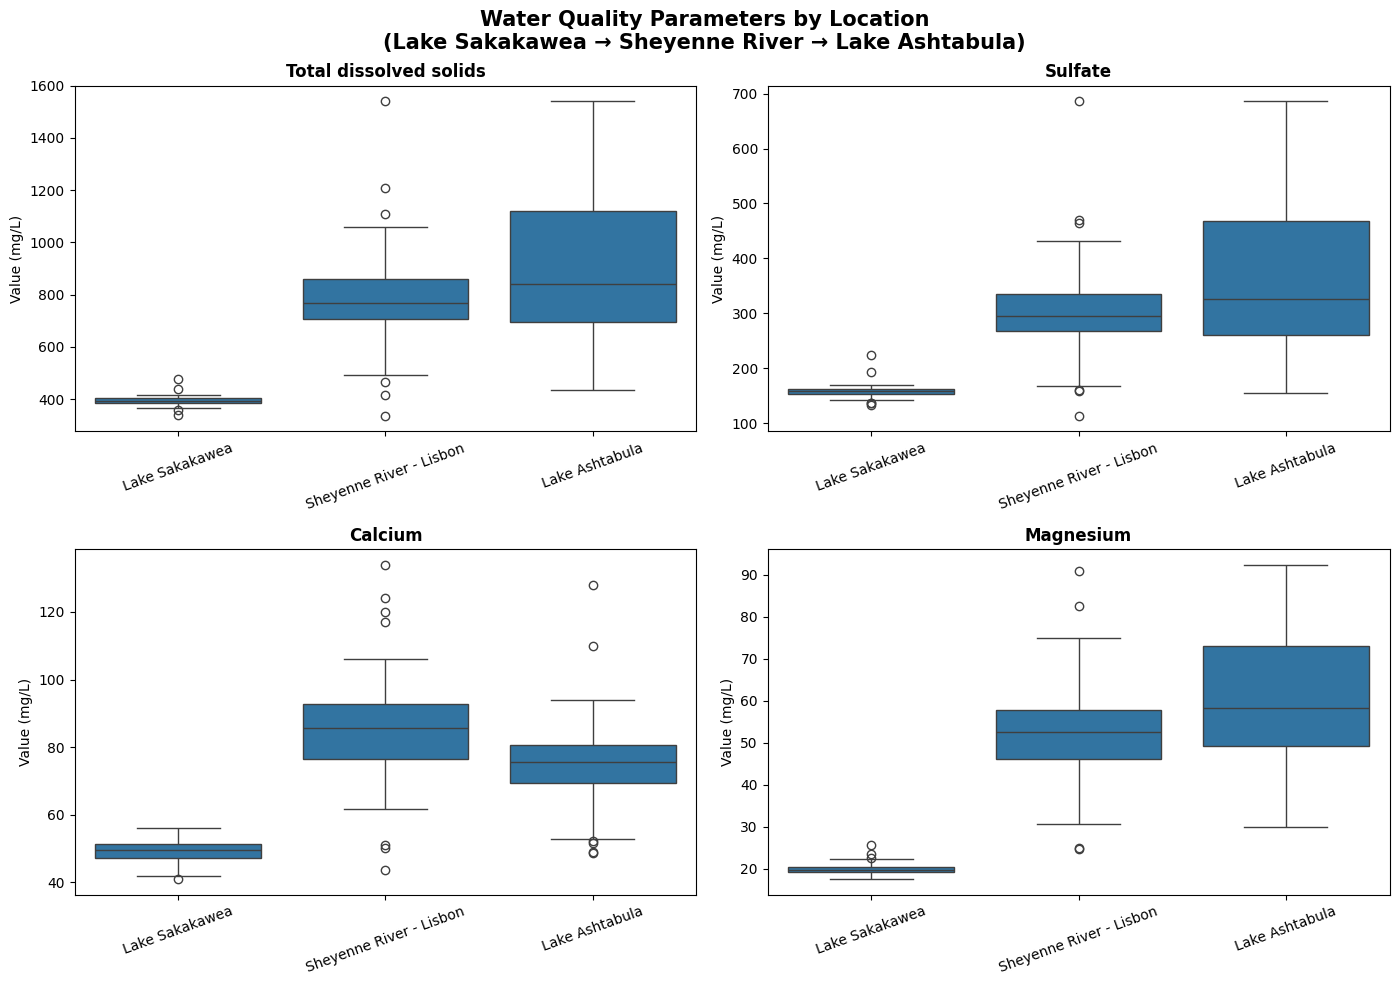

In [76]:
boxplot_params = ['Total dissolved solids', 'Sulfate', 'Calcium', 'Magnesium']
box_df = filtered_df[filtered_df['CharacteristicName'].isin(boxplot_params)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Water Quality Parameters by Location\n(Lake Sakakawea → Sheyenne River → Lake Ashtabula)',
             fontsize=15, fontweight='bold')

for ax, param in zip(axes.flatten(), boxplot_params):
    subset = box_df[box_df['CharacteristicName'] == param]

    unit_series = filtered_df[filtered_df['CharacteristicName'] == param]['ResultMeasure/MeasureUnitCode']
    unit = unit_series.mode()[0] if not unit_series.empty else ''

    sns.boxplot(data=subset, x='location_name', y='ResultMeasureValue', ax=ax)

    ax.set_title(param, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(f'Value ({unit})')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.subplots_adjust(left=0.05)
plt.show()

> **Interpretation:** The boxplots compare the spread and median values of TDS, sulfate, calcium, and magnesium across the three locations. This helps identify whether certain parts of the canal system show consistently higher concentrations or greater variability in water quality.

### Graph 2 – Average TDS Trend Along the Canal

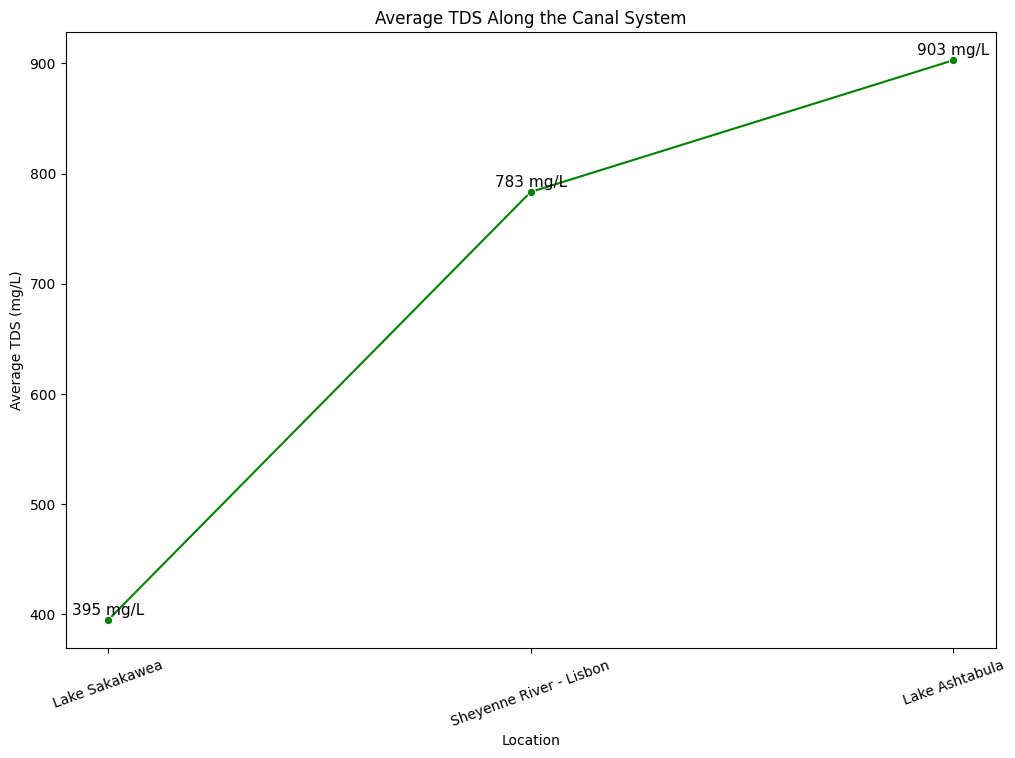

In [77]:
fig2, ax2 = plt.subplots(figsize=(12, 8))

sns.lineplot(
    data=tds_means,
    x='location_name',
    y='Mean',
    marker='o',
    color='green',
    ax=ax2
)

for i, row in tds_means.iterrows():
    ax2.text(row['location_name'], row['Mean'] + 5,
             f"{row['Mean']:.0f} mg/L",
             ha='center', fontsize=11)

ax2.set_title('Average TDS Along the Canal System')
ax2.set_xlabel('Location')
ax2.set_ylabel('Average TDS (mg/L)')
plt.xticks(rotation=20)

plt.show()

> **Interpretation:** The average TDS trend shows how dissolved solids change as water moves from Lake Sakakawea through the Sheyenne River into Lake Ashtabula, one of the primary questions posed by the client.

## 9. Dynamic TDS Mixing Function

In [78]:
def tds_mixing(pipe_flow, pipe_tds, river_flow, river_tds):
    """
    Calculates the mixed TDS concentration when two water sources combine.

    Parameters:
        pipe_flow  (float): Flow rate from the canal/pipe (cfs)
        pipe_tds   (float): TDS concentration of canal water (mg/L)
        river_flow (float): Flow rate of the receiving river (cfs)
        river_tds  (float): TDS concentration of river water (mg/L)

    Returns:
        float: Mixed TDS concentration (mg/L)
    """
    mixed_tds = (pipe_flow * pipe_tds + river_flow * river_tds) / (pipe_flow + river_flow)
    return round(mixed_tds, 2)

# Test with one example
result = tds_mixing(pipe_flow=6, pipe_tds=600, river_flow=20, river_tds=700)
print(f'Example mixed TDS: {result} mg/L')

Example mixed TDS: 676.92 mg/L


> This function estimates mixed TDS after canal water enters the river system using different flow and concentration scenarios:*C_mixed = (Q1×C1 + Q2×C2) / (Q1 + Q2)**

## 10. Scenario Testing

In [79]:
scenarios = pd.DataFrame({
    'Scenario':    ['Low Flow',  'Base Case', 'High Flow'],
    'pipe_flow':   [6,           6,           6],
    'pipe_tds':    [550,         600,         650],
    'river_flow':  [15,          20,          25],
    'river_tds':   [680,         700,         720]
})

scenarios['Mixed TDS (mg/L)'] = scenarios.apply(
    lambda row: tds_mixing(row['pipe_flow'], row['pipe_tds'], row['river_flow'], row['river_tds']),
    axis=1
)

scenarios

,Scenario,pipe_flow,pipe_tds,river_flow,river_tds,Mixed TDS (mg/L)
0,Low Flow,6,550,15,680,642.86
1,Base Case,6,600,20,700,676.92
2,High Flow,6,650,25,720,706.45


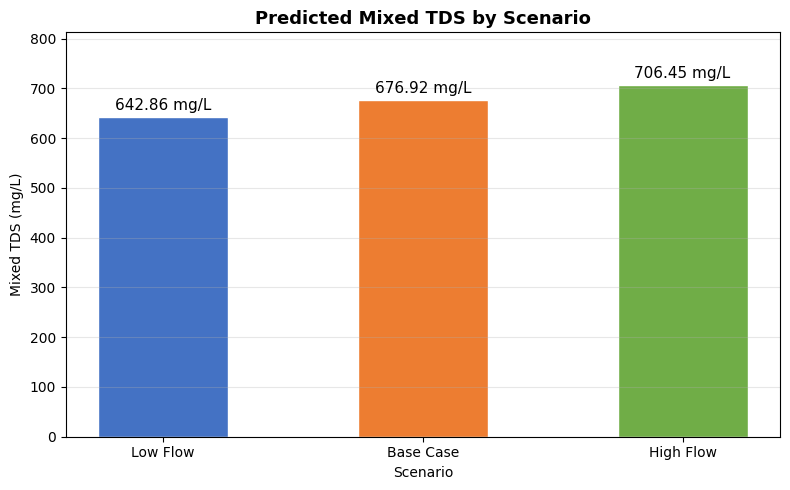

In [80]:
fig3, ax3 = plt.subplots(figsize=(8, 5))

ax3.bar(scenarios['Scenario'], scenarios['Mixed TDS (mg/L)'],
        color=['#4472C4', '#ED7D31', '#70AD47'],
        edgecolor='white', width=0.5)

for i, row in scenarios.iterrows():
    ax3.text(i, row['Mixed TDS (mg/L)'] * 1.02,
             f"{row['Mixed TDS (mg/L)']} mg/L",
             ha='center', fontsize=11)

ax3.set_title('Predicted Mixed TDS by Scenario', fontsize=13, fontweight='bold')
ax3.set_xlabel('Scenario')
ax3.set_ylabel('Mixed TDS (mg/L)')

ax3.set_ylim(0, max(scenarios['Mixed TDS (mg/L)']) * 1.15)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> **Interpretation:** The scenarios show how changing pipe and river flow rates affects the predicted TDS in Lake Ashtabula. Higher river flow dilutes the canal contribution more, while higher pipe concentration raises the mixed result.

## 11. Initial Results and Interpretation

TDS, calcium, and sulfate tend to increase from Lake Sakakawea to Lake Ashtabula, suggesting dissolved materials may accumulate along the pathway. pH slightly decreases, but TDS and sulfate appear to be the main concerns for monitoring.

## 12. Bias / Ethics / Coding Choices

Several coding choices in this analysis may influence results:

- **Missing value removal:** Dropping rows with missing result values reduces noise but may also remove potentially useful observations, which could skew summary statistics if missing data is not random.
- **Location selection:** Focusing on three specific locations simplifies the comparison but hides variation at other sites along the route.
- **Parameter selection:** Choosing which parameters to analyze affects which trends appear most important. Parameters not included may also be changing.
- **Graph type and scale:** Boxplots can make distributions appear wider or narrower depending on scale. Outliers in this dataset are real measurements, not errors, so they were retained.
- **TDS mixing model assumptions:** The mixing function assumes complete and instantaneous mixing, which may not reflect real-world hydraulic behavior in the lake or river reach.

These choices were made to improve clarity and reproducibility, but they still introduce analyst judgment into the final results.